# without spliting attack

# Mount Drive

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# Imports

In [2]:
#!pip install tensorflow

In [3]:
import numpy as np
import os
import json
import joblib
import matplotlib.pyplot as plt

# Paths

In [4]:
BASE_PATH = "../Data/"
DATA_PATH = os.path.join(BASE_PATH, "swat_preprocessed")
MODEL_PATH = os.path.join(BASE_PATH, "models")

os.makedirs(MODEL_PATH, exist_ok=True)

# Load Windowed Data

In [5]:
X_train = np.load(os.path.join(DATA_PATH, "X_train.npy"))


In [6]:
X_val = np.load(os.path.join(DATA_PATH, "X_val.npy"))


In [7]:
X_test = np.load(os.path.join(DATA_PATH, "X_test.npy"))


In [8]:
y_test = np.load(os.path.join(DATA_PATH, "y_test.npy"))



# Build Autoencoder

In [9]:
import torch
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_size=64):
        super().__init__()

        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, n_features, batch_first=True)

    def forward(self, x):
        encoded, _ = self.encoder(x)
        decoded, _ = self.decoder(encoded)
        return decoded

In [10]:
import torch

X_train_t = torch.from_numpy(X_train).float()
X_val_t   = torch.from_numpy(X_val).float()
X_test_t  = torch.from_numpy(X_test).float()

In [12]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import gc

# ====== CONFIG ======
BATCH_SIZE = 32
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
# ====== INIT MODEL (FIX) ======
n_features = X_train.shape[2]

model = LSTMAutoencoder(n_features=n_features, hidden_size=64)
model = model.to(DEVICE)

# ====== LOSS + OPTIMIZER (FIX) ======
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ====== DATASET ======
train_dataset = TensorDataset(X_train_t, X_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

if 'X_val_t' in globals():
    val_dataset = TensorDataset(X_val_t, X_val_t)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
else:
    val_loader = None

# ====== TRAINING ======
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        output = model(xb)
        loss = criterion(output, yb)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        del xb, yb, output, loss

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)

    # ====== VALIDATION ======
    if val_loader is not None:
        model.eval()
        val_epoch_loss = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                output = model(xb)
                loss = criterion(output, yb)

                val_epoch_loss += loss.item()

                del xb, yb, output, loss

        val_epoch_loss /= len(val_loader)
        val_losses.append(val_epoch_loss)

        print(f"Epoch [{epoch+1}/{EPOCHS}] "
              f"Train Loss: {epoch_loss:.6f} | Val Loss: {val_epoch_loss:.6f}")
    else:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {epoch_loss:.6f}")

    # ====== CLEANUP ======
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()



Using device: cuda
Epoch [1/10] Train Loss: 0.002259 | Val Loss: 0.001942
Epoch [2/10] Train Loss: 0.001538 | Val Loss: 0.001903
Epoch [3/10] Train Loss: 0.001531 | Val Loss: 0.001892
Epoch [4/10] Train Loss: 0.001528 | Val Loss: 0.001875
Epoch [5/10] Train Loss: 0.001527 | Val Loss: 0.001875
Epoch [6/10] Train Loss: 0.001526 | Val Loss: 0.001869
Epoch [7/10] Train Loss: 0.001526 | Val Loss: 0.001875
Epoch [8/10] Train Loss: 0.001525 | Val Loss: 0.001864
Epoch [9/10] Train Loss: 0.001525 | Val Loss: 0.001864
Epoch [10/10] Train Loss: 0.001525 | Val Loss: 0.001865


In [13]:
batch_size = 32  # try 16 or 8 if still OOM

model.eval()
results = []

with torch.no_grad():
    for i in range(0, len(X_test_t), batch_size):
        batch = X_test_t[i:i+batch_size].to(DEVICE)

        recon = model(batch)

        err = ((recon - batch) ** 2).mean(dim=(1,2))
        results.append(err.cpu())

errors = torch.cat(results).numpy()

In [14]:
batch_size = 32  # reduce if needed

model.eval()
val_results = []

with torch.no_grad():
    for i in range(0, len(X_val_t), batch_size):
        batch = X_val_t[i:i+batch_size].to(DEVICE)

        recon = model(batch)

        err = ((recon - batch) ** 2).mean(dim=(1,2))
        val_results.append(err.cpu())

val_errors = torch.cat(val_results).numpy()

In [18]:
threshold = np.percentile(val_errors, 97)

In [19]:
y_pred = (errors > threshold).astype(int)

In [20]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.95      0.98     69164
         1.0       0.94      1.00      0.97     51020

    accuracy                           0.97    120184
   macro avg       0.97      0.98      0.97    120184
weighted avg       0.98      0.97      0.97    120184



In [21]:
joblib.dump(model.state_dict(), os.path.join(MODEL_PATH, "lstm_autoencoder.pth"))

['../Data/models\\lstm_autoencoder.pth']

In [22]:
cm = confusion_matrix(y_test, y_pred)


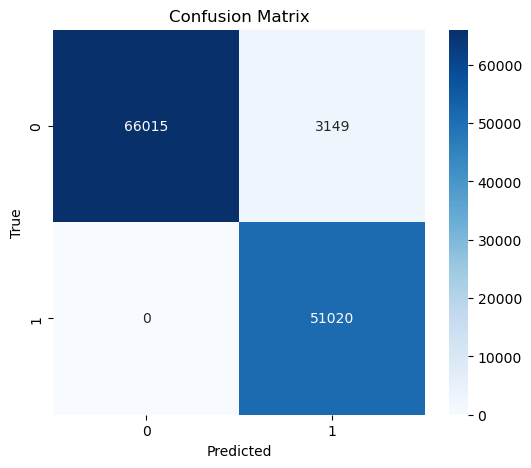

In [23]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()